# Comparison of RNA velocity methods for CCC matrix inference

In this tutorial, we compare the CCC matrix inference when the RNA velocities of target genes of the pathways are computed with different trajectory inference methods. Specifically, we compare [scVelo](https://www.nature.com/articles/s41587-020-0591-3) with [UnitVelo](https://www.nature.com/articles/s41467-022-34188-7). We also stress that the main advencement of the scRICH model is the robust identification of CCC signaling modes at the meta-cell resolution, while the calculation of a CCC matrix is a downstream task that can be performed by other existing tools as well. Specifically, Tutorial-3 shows how scRICH can be combined with LIANA+ for CCC inference. 

### 0-Import packages

In [65]:
import scvelo as scv
import scanpy as sc
import os
import string
import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2
import scrich as ri

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import warnings
warnings.simplefilter("ignore", DeprecationWarning)

### 1-scVelo-based CCC matrix inference

First, we compute the CCC matrix for the IGF pathway. This is the same approach used in Tutorial-1.

In [50]:
adata = scv.datasets.gastrulation_erythroid()

In [51]:
scv.pp.filter_and_normalize(adata, min_shared_counts=20)
scv.pp.moments(adata, n_pcs=30, n_neighbors=30)

Filtered out 47456 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Logarithmized X.
computing neighbors


/Users/federicobocci/Desktop/commflow_project/ccc_project/commflow_env/lib/python3.9/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/var/folders/h8/221dz5dn3t7fnjtc80l_3p7c0000gn/T/ipykernel_8192/3097972183.py:2: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
/Users/federicobocci/Desktop/commflow_project/ccc_project/commflow_env/lib/python3.9/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:02) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [52]:
scv.tl.velocity(adata, mode='stochastic')
scv.tl.velocity_graph(adata)

computing velocities
    finished (0:00:02) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/8 cores)


  0%|          | 0/9815 [00:00<?, ?cells/s]

    finished (0:00:07) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [53]:
ri.tl.pathways_overview(adata, human=False)

Scanning for cell-cell communication pathways...
Identified 11 pathways with at least one Receptor and one Ligand detected


In [54]:
ri.tl.all_path_sim(adata, 'celltype', method='expression', pathways_to_use=['IGF'], target=False, human=False,
                       neighbor_average=True, print_info=False)
ri.tl.permutation_testing(adata, key='celltype')

['IGF']
Analyzing the IGF pathway...
running clustering
finished sim_mat for IGF, starting spectral analysis

running consensus
dict_keys(['celltype_colors', 'log1p', 'neighbors', 'velocity_params', 'velocity_graph', 'velocity_graph_neg', 'pathways', 'paths_overview', 'selected_pathways', 'SymNMF', 'fraction_mat']) 4


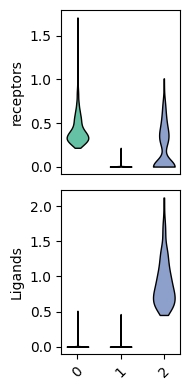

In [55]:
ri.pl.mode_violin(adata, 'IGF_modes', savefig=False, showfig=True)

In [56]:
ri.tl.rename_modes(adata, 'IGF', {0: 'Receiver', 1: 'Inactive', 2: 'Sender/Receiver'})

In [57]:
ri.tl.import_database(adata, ['IGF'], species='mouse', unspliced=True) #, input_target={'IGF': igf})
ri.tl.compute_ccc_matrix(adata, 'IGF', key='celltype', include_target=True, use_velocity=True, conversion=True,
                             model='mass_action', min_cells=10)

The inferred CCC matrix is stored in *adata.uns* and can be accessed as follows:

In [58]:
ccc_mat_scvelo = adata.uns['ccc_mat']['IGF']
ccc_mat_scvelo

{'states': ['Blood progenitors 1-Inactive',
  'Blood progenitors 1-Receiver',
  'Blood progenitors 1-Sender/Receiver',
  'Blood progenitors 2-Inactive',
  'Blood progenitors 2-Receiver',
  'Blood progenitors 2-Sender/Receiver',
  'Erythroid1-Inactive',
  'Erythroid1-Receiver',
  'Erythroid1-Sender/Receiver',
  'Erythroid2-Inactive',
  'Erythroid2-Receiver',
  'Erythroid2-Sender/Receiver',
  'Erythroid3-Inactive',
  'Erythroid3-Receiver',
  'Erythroid3-Sender/Receiver'],
 'mat': array([[0.00087459, 0.00218082, 0.00143327, 0.00094901, 0.00307454,
         0.00179073, 0.00162565, 0.00460684, 0.        , 0.00194142,
         0.00557576, 0.        , 0.00169477, 0.00375863, 0.        ],
        [0.00090457, 0.00225553, 0.00148238, 0.00098153, 0.00317984,
         0.00185208, 0.00168136, 0.00476464, 0.        , 0.00200796,
         0.00576675, 0.        , 0.00175286, 0.00388741, 0.        ],
        [0.0130659 , 0.03233716, 0.02133604, 0.01417768, 0.04550091,
         0.02663205, 0.02428619, 

### 2-UnitVelo-based CCC inference

Now, we repeat the same calculation when RNA velocities are computed with UnitVelo. A version of the same scRNA-seq dataset preprocessed via UnitVelo is available in scRICH's Github repository. We decided against including the UnitVelo package within the scRICH environment to limit the numnber of dependencies and thus increased the robustness of scRICH. The calculation of RNA velocity with UnitVelo on this daatset can be easily reproduced by following their dedicated [tutorial](https://unitvelo.readthedocs.io/en/latest/Figure2_ErythroidMouse.html).

In [59]:
adata_uv = sc.read_h5ad('datasets/erythroid_lineage_uniTVelo.h5ad')

The number of genes considered by the two RNA velocity methods is different, so we first consider the only the set of shared genes:

In [60]:
common_genes = adata.var_names.intersection(adata_uv.var_names)
adata_filtered = adata[:, common_genes].copy()

In [61]:
adata_filtered.layers['velocity'] = adata_uv.layers['velocity']

In [62]:
ri.tl.import_database(adata_filtered, ['IGF'], species='mouse', unspliced=True)
ri.tl.compute_ccc_matrix(adata_filtered, 'IGF', key='celltype', include_target=True, use_velocity=True, conversion=True,
                                     model='mass_action', min_cells=10)

The UnitVelo-based CCC matrix can be similarly accessed:

In [63]:
ccc_mat_unitvelo = adata_filtered.uns['ccc_mat']['IGF']
ccc_mat_unitvelo

{'states': ['Blood progenitors 1-Inactive',
  'Blood progenitors 1-Receiver',
  'Blood progenitors 1-Sender/Receiver',
  'Blood progenitors 2-Inactive',
  'Blood progenitors 2-Receiver',
  'Blood progenitors 2-Sender/Receiver',
  'Erythroid1-Inactive',
  'Erythroid1-Receiver',
  'Erythroid1-Sender/Receiver',
  'Erythroid2-Inactive',
  'Erythroid2-Receiver',
  'Erythroid2-Sender/Receiver',
  'Erythroid3-Inactive',
  'Erythroid3-Receiver',
  'Erythroid3-Sender/Receiver'],
 'mat': array([[2.89383272e-87, 1.81396124e-05, 2.94519637e-02, 7.03204809e-96,
         7.30487753e-53, 3.69099080e-06, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.99301597e-87, 1.87609828e-05, 3.04611342e-02, 7.27306458e-96,
         7.55506860e-53, 3.81745359e-06, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+0

In [67]:
def matching_interactions(A, B, eps=0.):
    v, w = np.ndarray.flatten(A), np.ndarray.flatten(B)
    v[v < eps] = 0
    w[w < eps] = 0
    pos, neg, tot = 0, 0, np.count_nonzero(v)
    for i in range(v.size):
        if v[i]>0 and w[i]>0:
            pos += 1
        elif v[i]>0 and w[i]==0:
            neg += 1
    return 100*float(pos)/tot

matching_interactions(ccc_mat_scvelo['mat'], ccc_mat_unitvelo['mat'])

50.0